# Visión por Computadora
## Clase 3 — Filtrado, convolución y detección de bordes
### Unidad 1 · Fundamentos y características visuales

**Laboratorio práctico (Google Colab).** En la clase anterior aprendiste a **operar** cada píxel por separado: brillo, contraste, ecualización. Hoy damos un salto: en vez de tocar un píxel a la vez, miramos cada píxel **junto a sus vecinos**. Esa operación se llama **convolución**, y es —literalmente— la misma que una red neuronal convolucional (CNN) aprende sola en la Unidad 2.

---

#### Cómo trabajar en este notebook

1. Ejecuta las celdas **en orden**, de arriba hacia abajo, con el botón ▶ o con `Shift + Enter`.



---

In [1]:
# ----------------------------------------------------------------------------
# Cada 'import' trae una librería (una caja de herramientas ya hecha).
# La palabra reservada "as" le pone un apodo corto para escribir menos.
# ----------------------------------------------------------------------------
import cv2                       # OpenCV: la librería de visión por computadora
import numpy as np               # NumPy: maneja tablas de números (así se guarda una imagen)
import matplotlib.pyplot as plt  # Matplotlib: para dibujar imágenes y gráficos

# Esta línea es especial de Colab/Jupyter: hace que los gráficos aparezcan
# DENTRO del notebook, justo debajo de cada celda (y no en una ventana aparte).
%matplotlib inline

print("Todo listo. Las librerías se cargaron correctamente.")  # aviso de que ya podemos seguir

Todo listo. Las librerías se cargaron correctamente.


---

## Parte 1 — La convolución, a mano

Antes de tocar ninguna foto, entendamos la operación con números que puedas seguir con la vista.

Una **convolución** desliza una ventanita de números (el **kernel** o filtro) sobre la imagen. En cada posición: multiplica cada número del kernel por el píxel que tiene debajo, y **suma todo**. Ese único número es el píxel de salida. Vamos a calcular **una** posición, paso a paso.

In [13]:
# Un pedacito de imagen de 3x3 píxeles (9 números). El 200 del centro es un tono claro,
# rodeado de vecinos de 100 (más oscuros). Queremos ver qué pasa al promediarlo con ellos.
parche = np.array([[100, 100, 100],   # fila 0
                   [100, 200, 100],   # fila 1  (el 200 está en el centro)
                   [100, 100, 100]],  # fila 2
                  dtype=np.float32)    # float32: decimales, para no perder precisión al dividir

# El kernel de PROMEDIO 3x3: nueve pesos iguales, cada uno vale 1/9.
# np.ones((3,3)) crea una matriz de unos; al dividir entre 9, cada celda queda en 1/9.
kernel_promedio = np.ones((3, 3), dtype=np.float32) / 9.0

print("Parche (los 9 píxeles):")
print(parche.astype(int))
print("\nKernel de promedio (cada peso = 1/9 ≈ 0.111):")
print(np.round(kernel_promedio, 3))

Parche (los 9 píxeles):
[[100 100 100]
 [100 200 100]
 [100 100 100]]

Kernel de promedio (cada peso = 1/9 ≈ 0.111):
[[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]]


In [3]:
# La convolución en ESTA posición es: multiplicar elemento a elemento y sumar todo.
#   parche * kernel  -> multiplica casilla con casilla (mismo tamaño 3x3)
#   .sum()           -> suma los 9 resultados en un solo número
productos = parche * kernel_promedio        # 9 multiplicaciones, una por casilla
salida = float(productos.sum())             # sumamos las 9 -> el píxel de salida

print("Cada término (parche * peso):")
print(np.round(productos, 1))
print("\nPíxel de salida (la suma de todo):", round(salida, 1))
print("\nEl 200 del centro se convirtió en ~111: se 'diluyó' con sus vecinos de 100.")
print("Eso es, exactamente, SUAVIZAR un píxel.")

Cada término (parche * peso):
[[11.1 11.1 11.1]
 [11.1 22.2 11.1]
 [11.1 11.1 11.1]]

Píxel de salida (la suma de todo): 111.1

El 200 del centro se convirtió en ~111: se 'diluyó' con sus vecinos de 100.
Eso es, exactamente, SUAVIZAR un píxel.


**La idea clave del curso, aquí:** ese kernel de promedio lo *diseñamos* nosotros a mano. En la Unidad 2, una CNN tendrá cientos de kernels como este, pero **no los diseñaremos**: la red ajustará sus números sola, a partir de los datos. La operación —multiplicar y sumar sobre una ventana— es **idéntica**; lo único que cambia es **quién elige los pesos**.

## Parte 2 — Sube tu propia imagen

Ahora trabajaremos con una foto tuya. Lo ideal: una imagen con **bordes claros** (un edificio, un objeto sobre una mesa, texto) para que la detección de bordes luzca. Al ejecutar la celda aparecerá un botón **Elegir archivos**.

Saving paisaje.png to paisaje.png


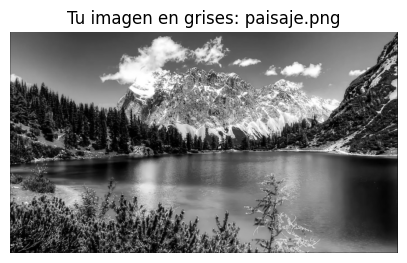

¡Listo! A partir de ahora se usará tu imagen. Tamaño (filas, columnas): (1602, 2806)


In [4]:
# ----------------------------------------------------------------------------
# SUBIDA DE ARCHIVO EN COLAB
# 'google.colab.files' solo existe en Colab; por eso lo importamos aquí dentro.
# ----------------------------------------------------------------------------
from google.colab import files          # herramienta de Colab para subir/bajar archivos

subidos = files.upload()                # abre el botón "Elegir archivos"; devuelve un diccionario:
                                        #   { "nombre_del_archivo": bytes_del_archivo }

work_gray = None                         # aquí guardaremos tu imagen en grises

if len(subidos) == 0:                    # si no elegiste ningún archivo...
    print("No subiste ninguna imagen. Vuelve a ejecutar la celda y elige un archivo.")
else:
    nombre = list(subidos.keys())[0]     # tomamos el nombre del primer (y único) archivo
    datos = subidos[nombre]              # los bytes crudos de ese archivo

    # np.frombuffer convierte esos bytes en una lista de números (todavía no es una imagen):
    buffer = np.frombuffer(datos, dtype=np.uint8)

    # cv2.imdecode interpreta esos números y arma la imagen a color (en orden BGR de OpenCV):
    img_color = cv2.imdecode(buffer, cv2.IMREAD_COLOR)

    # Hoy trabajamos casi todo en grises: un borde es un cambio de intensidad y no necesita color.
    # cv2.cvtColor convierte de color (BGR) a una sola capa de gris:
    work_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # Mostramos tu imagen ya en grises:
    plt.figure(figsize=(5, 4))
    plt.imshow(work_gray, cmap="gray", vmin=0, vmax=255)  # vmin/vmax fija 0=negro, 255=blanco
    plt.title(f"Tu imagen en grises: {nombre}")
    plt.axis("off")
    plt.show()
    print("¡Listo! A partir de ahora se usará tu imagen. Tamaño (filas, columnas):", work_gray.shape)

---

## Parte 3 — Suavizado: promediar con los vecinos

Suavizar = reemplazar cada píxel por una mezcla de sus vecinos. Sirve para **reducir ruido** y detalles finos, sobre todo antes de detectar bordes. Vemos los tres filtros clásicos, cada uno con un kernel distinto:

- **Promedio (`blur`)**: todos los vecinos pesan igual. Simple, pero difumina también los bordes.
- **Gaussiano (`GaussianBlur`)**: los vecinos cercanos pesan más. Suaviza sin destrozar tanto los bordes.
- **Mediana (`medianBlur`)**: toma el valor *del medio* de la vecindad. Excelente contra el ruido de puntos sueltos.

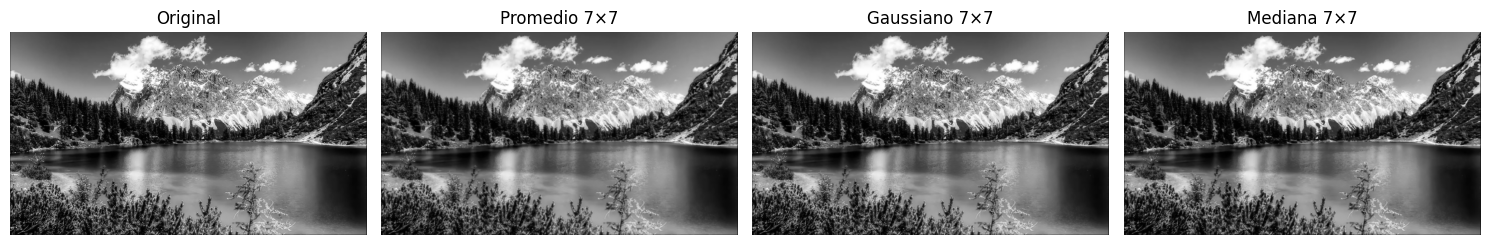

Fíjate: el gaussiano conserva mejor los bordes que el promedio. Compáralos de cerca.


In [16]:
# Aplicamos los tres suavizados a tu imagen en grises. El (7, 7) es el tamaño de la ventana:
# una ventana más grande mezcla más vecinos y suaviza más.
suave_prom   = cv2.blur(work_gray, (7, 7))              # promedio: ventana 7x7
suave_gauss  = cv2.GaussianBlur(work_gray, (7, 7), 0)   # gaussiano: el 0 = calcula la 'sigma' solo
suave_median = cv2.medianBlur(work_gray, 7)             # mediana: el 7 es el lado (debe ser impar)

# Preparamos una fila de 4 imágenes para compararlas de un vistazo:
imagenes = [work_gray, suave_prom, suave_gauss, suave_median]
titulos  = ["Original", "Promedio 7×7", "Gaussiano 7×7", "Mediana 7×7"]

fig, ejes = plt.subplots(1, 4, figsize=(15, 4))          # 1 fila, 4 columnas de gráficos
for eje, im, t in zip(ejes, imagenes, titulos):          # zip empareja cada hueco con su imagen
    eje.imshow(im, cmap="gray", vmin=0, vmax=255)         # misma escala 0..255 = comparación justa
    eje.set_title(t); eje.axis("off")
plt.tight_layout(); plt.show()

print("Fíjate: el gaussiano conserva mejor los bordes que el promedio. Compáralos de cerca.")

> **El tamaño del kernel manda:** cambia el `(7, 7)` por `(15, 15)` y vuelve a ejecutar. Verás que con una ventana grande la imagen queda mucho más borrosa: a más vecinos mezclados, más detalle se pierde.

---

## Parte 4 — Reducción de ruido: elige el filtro correcto

No todo ruido se limpia igual. Vamos a **ensuciar** tu imagen con ruido “sal y pimienta” (píxeles blancos y negros aleatorios) y comparar qué filtro lo limpia mejor. **Predice antes de ver:** ¿ganará el gaussiano o la mediana?

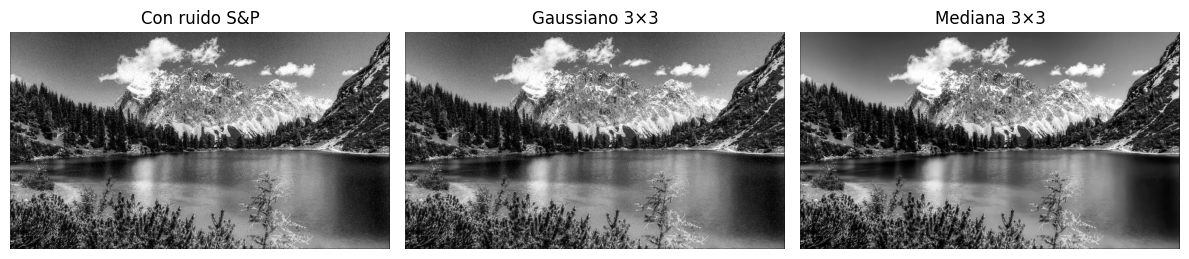

¿Cuál dejó una imagen más limpia? Fíjate en los puntos blancos y negros sueltos.


In [6]:
# 1) Creamos una COPIA de tu imagen para ensuciarla sin tocar la original.
ruidosa = work_gray.copy()

# 2) Generamos ruido: un número aleatorio entre 0 y 1 por cada píxel.
#    np.random.default_rng(0) fija una 'semilla' para que el ruido sea reproducible.
rng = np.random.default_rng(0)
mascara = rng.random(work_gray.shape)     # matriz de aleatorios, mismo tamaño que la imagen
prob = 0.04                                # 4% de píxeles afectados en total

# 3) Donde el aleatorio es muy bajo -> pimienta (negro=0). Muy alto -> sal (blanco=255).
ruidosa[mascara < prob / 2] = 0            # mitad del ruido: puntos negros
ruidosa[mascara > 1 - prob / 2] = 255      # otra mitad: puntos blancos

# 4) Intentamos limpiar el ruido de DOS formas distintas:
limpia_gauss  = cv2.GaussianBlur(ruidosa, (3, 3), 0)   # promedia el entorno
limpia_median = cv2.medianBlur(ruidosa, 3)             # toma el valor del medio

# 5) Comparamos las tres:
imagenes = [ruidosa, limpia_gauss, limpia_median]
titulos  = ["Con ruido S&P", "Gaussiano 3×3", "Mediana 3×3"]
fig, ejes = plt.subplots(1, 3, figsize=(12, 4))
for eje, im, t in zip(ejes, imagenes, titulos):
    eje.imshow(im, cmap="gray", vmin=0, vmax=255); eje.set_title(t); eje.axis("off")
plt.tight_layout(); plt.show()

print("¿Cuál dejó una imagen más limpia? Fíjate en los puntos blancos y negros sueltos.")

**Lo que deberías ver:** la **mediana** gana claramente. ¿Por qué? Un píxel blanco o negro suelto es un valor extremo; al ordenar la vecindad y tomar el del medio, la mediana simplemente lo descarta. El gaussiano, en cambio, *promedia* ese extremo con sus vecinos y deja una mancha gris. **La lección: el mejor filtro depende del tipo de ruido.**

---

## Parte 5 — Realce: el kernel que resalta

Si un kernel de promedio *suaviza*, otro kernel puede hacer lo contrario: **realzar** (sharpen). Lo aplicamos con `cv2.filter2D`, que es la función de convolución **genérica**: tú le das el kernel y ella lo desliza por toda la imagen. Es la misma función que usa OpenCV por dentro para el promedio, Sobel y todo lo demás.

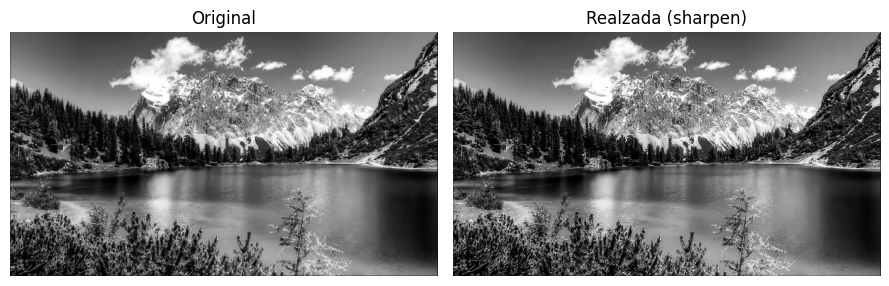

Mismo mecanismo (convolución con filter2D), otro kernel, efecto opuesto al suavizado.


In [7]:
# Kernel de realce: refuerza el centro (+5) y le RESTA sus vecinos (-1).
# Donde hay un cambio de intensidad (un detalle), esta resta lo acentúa.
kernel_realce = np.array([[ 0, -1,  0],
                          [-1,  5, -1],
                          [ 0, -1,  0]], dtype=np.float32)

# cv2.filter2D(imagen, profundidad, kernel): el -1 significa 'misma profundidad que la entrada'.
realzada = cv2.filter2D(work_gray, -1, kernel_realce)

fig, ejes = plt.subplots(1, 2, figsize=(9, 4))
ejes[0].imshow(work_gray, cmap="gray", vmin=0, vmax=255); ejes[0].set_title("Original"); ejes[0].axis("off")
ejes[1].imshow(realzada,  cmap="gray", vmin=0, vmax=255); ejes[1].set_title("Realzada (sharpen)"); ejes[1].axis("off")
plt.tight_layout(); plt.show()

print("Mismo mecanismo (convolución con filter2D), otro kernel, efecto opuesto al suavizado.")

> **Recuerda:** promedio, gaussiano y realce son todos **convoluciones**. Cambias los nueve números del kernel y cambias el efecto. Una CNN aprende *muchos* de estos kernels a la vez, y decide sus valores por sí misma.

---

## Parte 6 — Gradientes y bordes con Sobel

Un **borde** es un lugar donde la intensidad cambia bruscamente (de claro a oscuro). Medir ese cambio se llama **gradiente**. El filtro **Sobel** es un kernel que estima el gradiente en una dirección:

- `Sobel X` detecta bordes **verticales** (mide el cambio en horizontal).
- `Sobel Y` detecta bordes **horizontales** (mide el cambio en vertical).

Combinando ambos con la **magnitud** obtenemos *todos* los bordes.

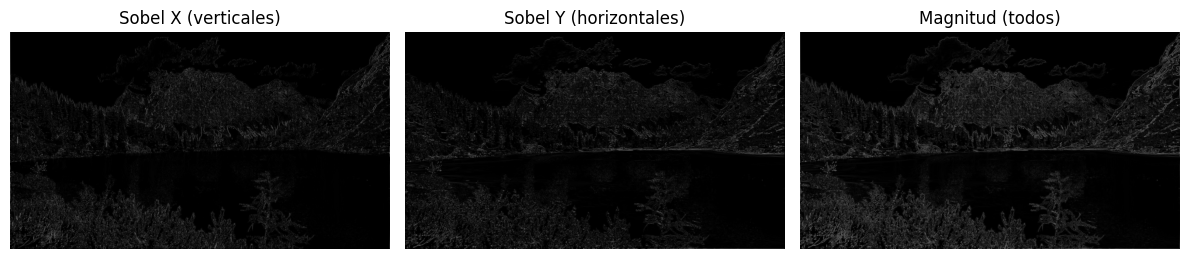

Sobel X e Y capturan direcciones distintas; la magnitud las une en un solo mapa de bordes.


In [8]:
# Sobel X e Y. Usamos cv2.CV_64F (decimales con signo) porque el gradiente puede ser negativo
# (de claro a oscuro) y no queremos perder esa información recortándola a 0.
#   (1, 0) = derivada en X (horizontal) ;  (0, 1) = derivada en Y (vertical)
#   ksize=3 = tamaño del kernel de Sobel (3x3)
sobel_x = cv2.Sobel(work_gray, cv2.CV_64F, 1, 0, ksize=3)   # bordes verticales
sobel_y = cv2.Sobel(work_gray, cv2.CV_64F, 0, 1, ksize=3)   # bordes horizontales

# La MAGNITUD combina las dos direcciones: raíz de (X^2 + Y^2), píxel por píxel.
magnitud = cv2.magnitude(sobel_x, sobel_y)
# Normalizamos el resultado al rango 0..255 para poder mostrarlo como imagen:
magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# np.abs = valor absoluto: mostramos la 'fuerza' del cambio sin importar su signo.
imagenes = [np.abs(sobel_x), np.abs(sobel_y), magnitud]
titulos  = ["Sobel X (verticales)", "Sobel Y (horizontales)", "Magnitud (todos)"]
fig, ejes = plt.subplots(1, 3, figsize=(12, 4))
for eje, im, t in zip(ejes, imagenes, titulos):
    eje.imshow(im, cmap="gray"); eje.set_title(t); eje.axis("off")
plt.tight_layout(); plt.show()

print("Sobel X e Y capturan direcciones distintas; la magnitud las une en un solo mapa de bordes.")

---

## Parte 7 — Canny: el detector de bordes de referencia

Sobel da bordes *gruesos y difusos*. **Canny** es un algoritmo más completo que entrega bordes **finos y limpios** (de un píxel de ancho). Usa **dos umbrales**: los cambios fuertes son borde seguro; los débiles solo se aceptan si están conectados a uno fuerte. Vamos a ver el efecto de mover esos umbrales.

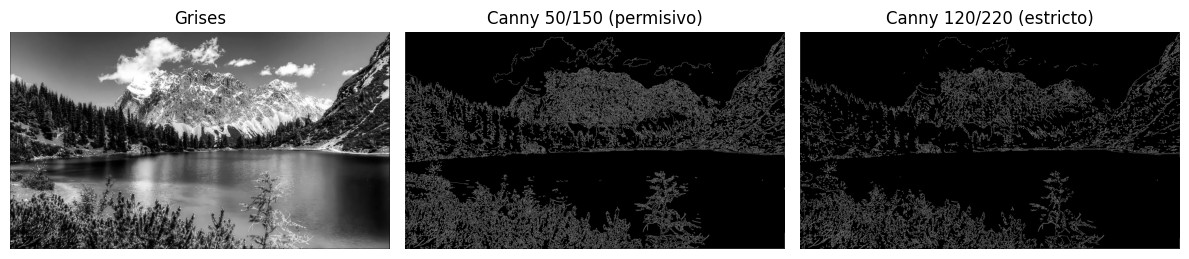

Umbrales bajos -> más detalle pero más ruido. Altos -> solo lo esencial.


In [9]:
# Canny funciona mejor sobre una imagen sin ruido, así que suavizamos un poco antes.
base = cv2.GaussianBlur(work_gray, (3, 3), 0)

# cv2.Canny(imagen, umbral_bajo, umbral_alto):
#   - por encima del umbral ALTO  -> borde seguro
#   - por debajo del umbral BAJO  -> no es borde
#   - entre ambos                 -> borde solo si toca uno seguro
canny_permisivo = cv2.Canny(base, 50, 150)    # umbrales bajos: más bordes (y más ruido)
canny_estricto  = cv2.Canny(base, 120, 220)   # umbrales altos: solo bordes fuertes

imagenes = [work_gray, canny_permisivo, canny_estricto]
titulos  = ["Grises", "Canny 50/150 (permisivo)", "Canny 120/220 (estricto)"]
fig, ejes = plt.subplots(1, 3, figsize=(12, 4))
for eje, im, t in zip(ejes, imagenes, titulos):
    eje.imshow(im, cmap="gray"); eje.set_title(t); eje.axis("off")
plt.tight_layout(); plt.show()

print("Umbrales bajos -> más detalle pero más ruido. Altos -> solo lo esencial.")

> **Ajustar los umbrales es el arte de Canny.** No hay un valor universal: depende de la imagen y de qué quieras extraer. En el ejercicio final buscarás los tuyos.

---

## Parte 8 — El puente: filtro diseñado vs filtro aprendido

Toda la clase de hoy tuvo un patrón: **nosotros elegimos el kernel** (promedio, realce, Sobel) según lo que queríamos lograr. Diseñar filtros a mano funciona, pero no escala: alguien tiene que saber de antemano qué filtro sirve para cada problema, y hay miles de patrones posibles.

La idea que revoluciona todo en la Unidad 2: **¿y si la máquina eligiera los kernels sola?** Eso es una CNN. La operación —convolución— es exactamente la que hiciste hoy. La diferencia es que sus pesos **se aprenden de los datos** en lugar de escribirse a mano.

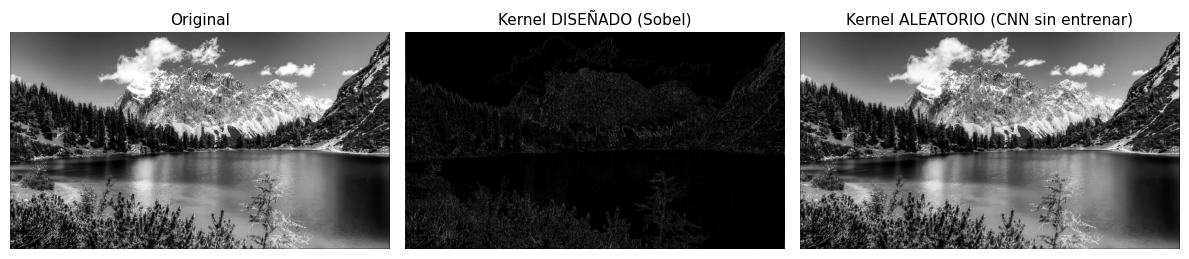

El diseñado extrae algo útil (bordes). El aleatorio, casi ruido.
Entrenar una CNN es, justamente, convertir kernels aleatorios en kernels útiles.


In [10]:
# Comparamos un filtro DISEÑADO por nosotros con un kernel ALEATORIO,
# como los que una CNN tiene ANTES de entrenar (sus pesos empiezan al azar).

# Kernel de Sobel vertical: diseñado a propósito para responder a bordes.
sobel_kernel = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]], dtype=np.float32)

# Kernel aleatorio: nueve números al azar entre -1 y 1. Sin ningún propósito... todavía.
rng = np.random.default_rng(42)
kernel_aleatorio = rng.uniform(-1, 1, size=(3, 3)).astype(np.float32)

# Aplicamos ambos con la misma función de convolución:
salida_disenada  = cv2.filter2D(work_gray, cv2.CV_64F, sobel_kernel)
salida_aleatoria = cv2.filter2D(work_gray, cv2.CV_64F, kernel_aleatorio)

imagenes = [work_gray, np.abs(salida_disenada), np.abs(salida_aleatoria)]
titulos  = ["Original", "Kernel DISEÑADO (Sobel)", "Kernel ALEATORIO (CNN sin entrenar)"]
fig, ejes = plt.subplots(1, 3, figsize=(12, 4))
for eje, im, t in zip(ejes, imagenes, titulos):
    eje.imshow(im, cmap="gray"); eje.set_title(t, fontsize=11); eje.axis("off")
plt.tight_layout(); plt.show()

print("El diseñado extrae algo útil (bordes). El aleatorio, casi ruido.")
print("Entrenar una CNN es, justamente, convertir kernels aleatorios en kernels útiles.")

---

## Parte 9 — TU TURNO: limpia y extrae los bordes

Aplica lo de hoy sobre tu propia imagen, en orden. Completa los pasos cambiando los números indicados y responde la pregunta escrita del final.

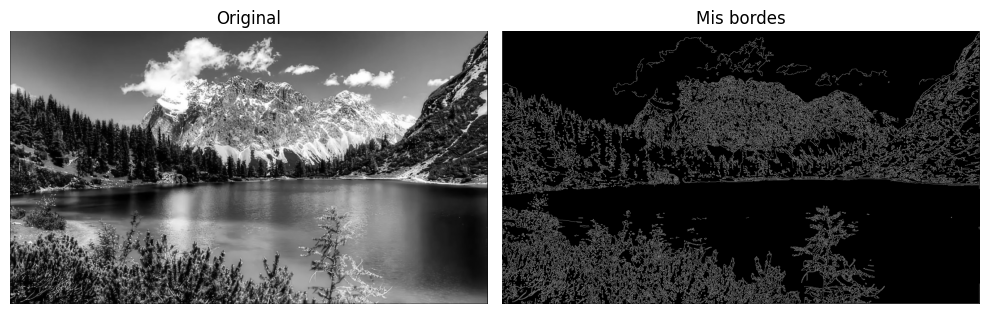

In [11]:
# TU TURNO — completa cada paso

# ---------- Paso 1: suaviza tu imagen ----------
# Elige UN filtro según el ruido de tu foto. Si tiene puntos sueltos, la mediana ayuda.
mi_suave = cv2.GaussianBlur(work_gray, (3, 3), 0)   # <-- cambia el filtro o el tamaño si quieres

# ---------- Paso 2: detecta bordes con Canny ----------
# Ajusta los dos umbrales hasta que se vea bien el contorno del objeto principal.
umbral_bajo = 50     # <-- ajústalo
umbral_alto = 150    # <-- ajústalo
mis_bordes = cv2.Canny(mi_suave, umbral_bajo, umbral_alto)

# ---------- Paso 3: muestra original y bordes lado a lado ----------
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(work_gray, cmap="gray", vmin=0, vmax=255); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(mis_bordes, cmap="gray"); ax[1].set_title("Mis bordes"); ax[1].axis("off")
plt.tight_layout(); plt.show()

### Paso 4 — Tu respuesta (escribe aquí)

**Pregunta:** ¿Qué relación tiene la convolución que usaste hoy (con `filter2D`, Sobel, blur) con las capas convolucionales de una red neuronal que veremos en la Unidad 2?

*Escribe tu respuesta en una o dos frases (doble clic para editar):*

> _(tu respuesta aquí)_

---

## Cierre

Hoy pasaste de operar píxel por píxel a operar **por vecindades**: la convolución. Diseñaste kernels para suavizar, limpiar ruido, realzar y detectar bordes con Sobel y Canny. Y viste el puente que sostiene toda la segunda mitad del curso: **una CNN hace exactamente esta operación, pero aprende sus kernels sola.** La próxima clase cerramos los fundamentos clásicos con características y segmentación, antes de entrar al deep learning.